Exercise - Random Forest Classifier for Customer Satisfaction

Problem Statement

* Develop a model that can predict customer satisfaction based on their purchasing behavior and product experience.

* The goal is to predict whether a customer is 'Satisfied' (1) or 'Dissatisfied' (0) with a product.

* Use a Random Forest classifier model for this task.

Necessary Steps to be performed

  1.  Import Libraries, Load and Explore Dataset: Import the necessary libraries, load and explore the `customer_satisfaction.csv` dataset for analysis.

  2.  Data Preprocessing: Prepare the data for the model by converting categorical features into a numerical format.

  3.  Define Features and Target: Separate the dataset into feature variables (`X`) and the target variable (`y`).

  4.  Split Data: Divide the data into a training set and a testing set.

  5.  Create and Train Model: Instantiate a `RandomForestClassifier` and train it on the training data.
 
  6.  Evaluate Model Performance: Test the model's accuracy on the unseen data.

  7.  Analyze Feature Importance: Analyze which features were most influential in the model's predictions.

  8.  Make Predictions: Use the model to predict the satisfaction level for a new customer.

---

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score

In [2]:
df=pd.read_csv('DataSets/customer_satisfaction.csv')
df.head()

,purchase_frequency,support_calls,product_quality,return_rate,satisfaction
0,7,1,High,0.063058,1
1,4,1,Low,0.107898,1
2,13,5,Medium,0.158145,0
3,11,0,High,0.063751,1
4,8,3,Medium,0.125178,1


In [3]:
df.info()


<class 'pandas.DataFrame'>
RangeIndex: 500 entries, 0 to 499
Data columns (total 5 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   purchase_frequency  500 non-null    int64  
 1   support_calls       500 non-null    int64  
 2   product_quality     500 non-null    str    
 3   return_rate         500 non-null    float64
 4   satisfaction        500 non-null    int64  
dtypes: float64(1), int64(3), str(1)
memory usage: 19.7 KB


In [4]:
le_pain = LabelEncoder()
df['product_quality_type_n']= le_pain.fit_transform(df['product_quality'])
print(df['product_quality_type_n'].value_counts())
df.head()

product_quality_type_n
0    264
2    192
1     44
Name: count, dtype: int64


,purchase_frequency,support_calls,product_quality,return_rate,satisfaction,product_quality_type_n
0,7,1,High,0.063058,1,0
1,4,1,Low,0.107898,1,1
2,13,5,Medium,0.158145,0,2
3,11,0,High,0.063751,1,0
4,8,3,Medium,0.125178,1,2


In [8]:
X=df[['purchase_frequency', 'support_calls', 'product_quality_type_n', 'return_rate']]
y=df['satisfaction']
print(X.shape)
print(y.shape)

(500, 4)
(500,)


In [9]:
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42)
print(len(X_train), len(X_test), len(y_train), len(y_test))

400 100 400 100


In [10]:
model = RandomForestClassifier(n_estimators=100, random_state=42)
model.fit(X_train, y_train)

,"random_state random_state: int, RandomState instance or None, default=NoneControls both the randomness of the bootstrapping of the samples usedwhen building trees (if ``bootstrap=True``) and the sampling of thefeatures to consider when looking for the best split at each node(if ``max_features < n_features``).See :term:`Glossary <random_state>` for details.",42
,"n_estimators n_estimators: int, default=100The number of trees in the forest... versionchanged:: 0.22 The default value of ``n_estimators`` changed from 10 to 100 in 0.22.",100
,"criterion criterion: {""gini"", ""entropy"", ""log_loss""}, default=""gini""The function to measure the quality of a split. Supported criteria are""gini"" for the Gini impurity and ""log_loss"" and ""entropy"" both for theShannon information gain, see :ref:`tree_mathematical_formulation`.Note: This parameter is tree-specific.",'gini'
,"max_depth max_depth: int, default=NoneThe maximum depth of the tree. If None, then nodes are expanded untilall leaves are pure or until all leaves contain less thanmin_samples_split samples.",None
,"min_samples_split min_samples_split: int or float, default=2The minimum number of samples required to split an internal node:- If int, then consider `min_samples_split` as the minimum number.- If float, then `min_samples_split` is a fraction and `ceil(min_samples_split * n_samples)` are the minimum number of samples for each split... versionchanged:: 0.18 Added float values for fractions.",2
,"min_samples_leaf min_samples_leaf: int or float, default=1The minimum number of samples required to be at a leaf node.A split point at any depth will only be considered if it leaves atleast ``min_samples_leaf`` training samples in each of the left andright branches. This may have the effect of smoothing the model,especially in regression.- If int, then consider `min_samples_leaf` as the minimum number.- If float, then `min_samples_leaf` is a fraction and `ceil(min_samples_leaf * n_samples)` are the minimum number of samples for each node... versionchanged:: 0.18 Added float values for fractions.",1
,"min_weight_fraction_leaf min_weight_fraction_leaf: float, default=0.0The minimum weighted fraction of the sum total of weights (of allthe input samples) required to be at a leaf node. Samples haveequal weight when sample_weight is not provided.",0.0
,"max_features max_features: {""sqrt"", ""log2"", None}, int or float, default=""sqrt""The number of features to consider when looking for the best split:- If int, then consider `max_features` features at each split.- If float, then `max_features` is a fraction and `max(1, int(max_features * n_features_in_))` features are considered at each split.- If ""sqrt"", then `max_features=sqrt(n_features)`.- If ""log2"", then `max_features=log2(n_features)`.- If None, then `max_features=n_features`... versionchanged:: 1.1 The default of `max_features` changed from `""auto""` to `""sqrt""`.Note: the search for a split does not stop until at least onevalid partition of the node samples is found, even if it requires toeffectively inspect more than ``max_features`` features.",'sqrt'
,"max_leaf_nodes max_leaf_nodes: int, default=NoneGrow trees with ``max_leaf_nodes`` in best-first fashion.Best nodes are defined as relative reduction in impurity.If None then unlimited number of leaf nodes.",None
,"min_impurity_decrease min_impurity_decrease: float, default=0.0A node will be split if this split induces a decrease of the impuritygreater than or equal to this value.The weighted impurity decrease equation is the following:: N_t / N * (impurity - N_t_R / N_t * right_impurity - N_t_L / N_t * left_impurity)where ``N`` is the total number of samples, ``N_t`` is the number ofsamples at the current node, ``N_t_L`` is the number of samples in theleft child, and ``N_t_R`` is the number of samples in the right child.``N``, ``N_t``, ``N_t_R`` and ``N_t_L`` all refer to the weighted sum,if ``sample_weight`` is passed... versionadded:: 0.19",0.0
,"bootstrap bootstr

In [11]:
accuracy = model.score(X_test, y_test)
print(f"Accuracy: {accuracy:.2f}")

Accuracy: 0.88


In [12]:
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.93      0.56      0.70        25
           1       0.87      0.99      0.93        75

    accuracy                           0.88       100
   macro avg       0.90      0.77      0.81       100
weighted avg       0.89      0.88      0.87       100



In [13]:
print(confusion_matrix(y_test, y_pred))

[[14 11]
 [ 1 74]]


In [14]:
print(model.feature_importances_)

[0.23239402 0.19271504 0.07110383 0.50378711]


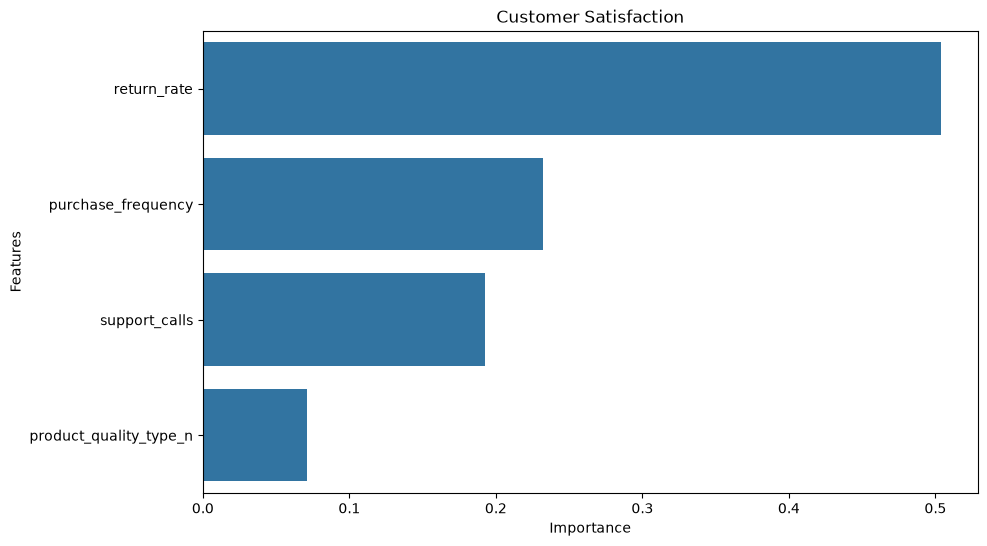

In [17]:
feature_importances = pd.Series(model.feature_importances_, index=X.columns).sort_values(ascending=False)
plt.figure(figsize=(10,6))
sns.barplot(x=feature_importances, y=feature_importances.index)
plt.title("Customer Satisfaction")
plt.xlabel("Importance")
plt.ylabel("Features")
plt.show()